# Tech Industry Layoffs vs AI Hiring Trend Analysis (2023-2026)

## Objective
Analyze tech industry layoffs, AI hiring, overall tech hiring, AI job growth, layoff rates, and AI-related layoffs from 2023 to 2026.

### Tools Used
- **Pandas** – data loading, cleaning, transformation and analysis
- **NumPy** – numerical/data transformation
- **Matplotlib** – visualization
- **Seaborn** – visualization and heatmap


In [33]:
%pip install pandas numpy matplotlib seaborn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")


Libraries imported successfully.


## 1. Data Loading
Load the Tech Industry Layoffs vs AI Hiring CSV dataset using Pandas.


In [91]:
df = pd.read_csv("data/Tech_Layoffs_vs_AI_Hiring_2023_2026.csv")
print("Dataset loaded successfully.")
print("Shape:", df.shape)
df.head()


Dataset loaded successfully.
Shape: (320, 12)


,ID,Year,Quarter,Company,Industry,Location,Layoffs,AI_Hiring,Tech_Hiring,AI_Job_Growth_Pct,Layoff_Rate_Pct,AI_Related_Layoff
0,1,2023,Q1,TechNova,Software,USA,1429,68,175,23.3,3.0,Yes
1,2,2023,Q1,CloudWorks,Cloud,India,329,213,708,11.6,4.3,Yes
2,3,2023,Q1,FinTechPro,FinTech,UK,567,99,667,20.8,5.3,No
3,4,2023,Q1,DataCore,Software,USA,1556,179,579,14.0,5.5,No
4,5,2023,Q1,ShopTech,E-commerce,India,133,234,313,22.6,3.7,Yes


## 2. Basic Dataset Exploration

Check rows, columns, data types, and statistical information before cleaning.


In [92]:
print("Rows and Columns:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
display(df.describe(include="all"))


Rows and Columns: (320, 12)

Column Names:
['ID', 'Year', 'Quarter', 'Company', 'Industry', 'Location', 'Layoffs', 'AI_Hiring', 'Tech_Hiring', 'AI_Job_Growth_Pct', 'Layoff_Rate_Pct', 'AI_Related_Layoff']

Data Types:
ID                     int64
Year                   int64
Quarter               object
Company               object
Industry              object
Location              object
Layoffs                int64
AI_Hiring              int64
Tech_Hiring            int64
AI_Job_Growth_Pct    float64
Layoff_Rate_Pct      float64
AI_Related_Layoff     object
dtype: object

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 320 entries, 0 to 319
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ID                 320 non-null    int64  
 1   Year               320 non-null    int64  
 2   Quarter            320 non-null    object 
 3   Company            320 non-null    object 
 4   I

,ID,Year,Quarter,Company,Industry,Location,Layoffs,AI_Hiring,Tech_Hiring,AI_Job_Growth_Pct,Layoff_Rate_Pct,AI_Related_Layoff
count,320.000000,320.000000,320,320,320,320,320.000000,320.000000,320.000000,320.000000,320.000000,320
unique,NaN,NaN,4,20,8,6,NaN,NaN,NaN,NaN,NaN,2
top,NaN,NaN,Q1,TechNova,Software,USA,NaN,NaN,NaN,NaN,NaN,No
freq,NaN,NaN,80,16,112,96,NaN,NaN,NaN,NaN,NaN,208
mean,160.500000,2024.500000,NaN,NaN,NaN,NaN,959.028125,256.790625,528.078125,27.303438,4.736562,NaN
std,92.520268,1.119785,NaN,NaN,NaN,NaN,491.627681,117.397150,200.171549,9.160055,2.009961,NaN
min,1.000000,2023.000000,NaN,NaN,NaN,NaN,133.000000,53.000000,151.000000,10.200000,1.200000,NaN
25%,80.750000,2023.750000,NaN,NaN,NaN,NaN,529.750000,163.000000,378.000000,20.200000,3.000000,NaN
50%,160.500000,2024.500000,NaN,NaN,NaN,NaN,950.000000,254.000000,523.000000,26.600000,4.700000,NaN
75%,240.250000,2025.250000,NaN,NaN,NaN,NaN,1406.750000,332.250000,702.500000,34.300000,6.400000,NaN


## 3. Data Cleaning

### Operations performed
1. Remove extra spaces from column names.
2. Strip spaces from text columns.
3. Convert numerical columns to numeric data types.
4. Check and handle missing values.
5. Remove duplicate rows.
6. Verify the cleaned dataset.


In [93]:
# 3.1 Clean column names
df.columns = df.columns.str.strip()

# 3.2 Strip whitespace from text columns
text_cols = df.select_dtypes(include="object").columns
for col in text_cols:
    df[col] = df[col].astype(str).str.strip()

# 3.3 Convert numerical columns
numeric_cols = [
    "Year", "Layoffs", "AI_Hiring", "Tech_Hiring",
    "AI_Job_Growth_Pct", "Layoff_Rate_Pct"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("Missing values before handling:")
display(df.isnull().sum())


Missing values before handling:


ID                   0
Year                 0
Quarter              0
Company              0
Industry             0
Location             0
Layoffs              0
AI_Hiring            0
Tech_Hiring          0
AI_Job_Growth_Pct    0
Layoff_Rate_Pct      0
AI_Related_Layoff    0
dtype: int64

In [6]:
# 3.4 Handle missing values
categorical_cols = df.select_dtypes(include="object").columns

for col in numeric_cols:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

for col in categorical_cols:
    if df[col].isnull().any():
        mode_value = df[col].mode()
        if not mode_value.empty:
            df[col] = df[col].fillna(mode_value[0])

# 3.5 Remove duplicate rows
duplicate_count = df.duplicated().sum()
df = df.drop_duplicates().reset_index(drop=True)

print("Duplicate rows found before removal:", duplicate_count)
print("Duplicate rows after cleaning:", df.duplicated().sum())
print("Missing values after cleaning:")
display(df.isnull().sum())


Duplicate rows found before removal: 0
Duplicate rows after cleaning: 0
Missing values after cleaning:


ID                   0
Year                 0
Quarter              0
Company              0
Industry             0
Location             0
Layoffs              0
AI_Hiring            0
Tech_Hiring          0
AI_Job_Growth_Pct    0
Layoff_Rate_Pct      0
AI_Related_Layoff    0
dtype: int64

## 4. NumPy Operation

Use NumPy to create an AI hiring category from the median AI hiring value.


In [94]:
ai_hiring_median = df["AI_Hiring"].median()

df["AI_Hiring_Level"] = np.where(
    df["AI_Hiring"] >= ai_hiring_median,
    "High",
    "Low"
)

print("Median AI Hiring:", ai_hiring_median)
display(df[["Company", "Year", "AI_Hiring", "AI_Hiring_Level"]].head())


Median AI Hiring: 254.0


,Company,Year,AI_Hiring,AI_Hiring_Level
0,TechNova,2023,68,Low
1,CloudWorks,2023,213,Low
2,FinTechPro,2023,99,Low
3,DataCore,2023,179,Low
4,ShopTech,2023,234,Low


## 5. Create Derived Columns

Calculate total hiring and an AI hiring share indicator.


In [95]:
df["Total_Hiring"] = df["AI_Hiring"] + df["Tech_Hiring"]

df["AI_Hiring_Share_Pct"] = (
    df["AI_Hiring"] / df["Total_Hiring"] * 100
).round(2)

df.head()


,ID,Year,Quarter,Company,Industry,Location,Layoffs,AI_Hiring,Tech_Hiring,AI_Job_Growth_Pct,Layoff_Rate_Pct,AI_Related_Layoff,AI_Hiring_Level,Total_Hiring,AI_Hiring_Share_Pct
0,1,2023,Q1,TechNova,Software,USA,1429,68,175,23.3,3.0,Yes,Low,243,27.98
1,2,2023,Q1,CloudWorks,Cloud,India,329,213,708,11.6,4.3,Yes,Low,921,23.13
2,3,2023,Q1,FinTechPro,FinTech,UK,567,99,667,20.8,5.3,No,Low,766,12.92
3,4,2023,Q1,DataCore,Software,USA,1556,179,579,14.0,5.5,No,Low,758,23.61
4,5,2023,Q1,ShopTech,E-commerce,India,133,234,313,22.6,3.7,Yes,Low,547,42.78


## 6. Save Cleaned Dataset

Save the cleaned and transformed dataset as a CSV file.


In [98]:
df.to_csv("data/Tech_Layoffs_vs_AI_Hiring_2023_2026_cleaned.csv", index=False)

print("Cleaned dataset saved successfully.")


Cleaned dataset saved successfully.


## 7. Exploratory Data Analysis (EDA)

Explore unique companies, industries, locations, years, missing values and duplicates.


In [69]:
print("Final Shape:", df.shape)
print("Number of Companies:", df["Company"].nunique())
print("Companies:", df["Company"].unique())
print("Industries:", df["Industry"].unique())
print("Locations:", df["Location"].unique())
print("Years:", sorted(df["Year"].unique()))

print("\nMissing values:")
display(df.isnull().sum())

print("Duplicate rows:", df.duplicated().sum())


Final Shape: (320, 15)
Number of Companies: 20
Companies: ['TechNova' 'CloudWorks' 'FinTechPro' 'DataCore' 'ShopTech' 'AIWorks'
 'PayMatrix' 'CyberSphere' 'CodeWave' 'NetSystems' 'AutoTech' 'DigitalHub'
 'ByteLabs' 'SmartData' 'SecureNet' 'FutureAI' 'MarketCloud' 'AppForge'
 'QuantumSoft' 'VisionTech']
Industries: ['Software' 'Cloud' 'FinTech' 'E-commerce' 'Artificial Intelligence'
 'Cybersecurity' 'Automation' 'Data Analytics']
Locations: ['USA' 'India' 'UK' 'Canada' 'Germany' 'Singapore']
Years: [np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]

Missing values:


ID                     0
Year                   0
Quarter                0
Company                0
Industry               0
Location               0
Layoffs                0
AI_Hiring              0
Tech_Hiring            0
AI_Job_Growth_Pct      0
Layoff_Rate_Pct        0
AI_Related_Layoff      0
AI_Hiring_Level        0
Total_Hiring           0
AI_Hiring_Share_Pct    0
dtype: int64

Duplicate rows: 0


## 8. Company-wise Layoffs and AI Hiring Analysis


In [70]:
company_summary = df.groupby("Company", as_index=False).agg(
    Total_Layoffs=("Layoffs", "sum"),
    Total_AI_Hiring=("AI_Hiring", "sum"),
    Total_Tech_Hiring=("Tech_Hiring", "sum"),
    Avg_AI_Job_Growth=("AI_Job_Growth_Pct", "mean"),
    Avg_Layoff_Rate=("Layoff_Rate_Pct", "mean")
).sort_values("Total_AI_Hiring", ascending=False)

display(company_summary)


,Company,Total_Layoffs,Total_AI_Hiring,Total_Tech_Hiring,Avg_AI_Job_Growth,Avg_Layoff_Rate
4,CloudWorks,13156,4784,9429,23.18125,4.78750
7,DataCore,17471,4596,8274,28.43125,4.24375
11,MarketCloud,15295,4568,7878,27.25000,4.37500
0,AIWorks,15977,4554,7690,28.31875,4.04375
8,DigitalHub,15192,4543,6606,27.03125,4.68125
12,NetSystems,17807,4499,8837,29.13125,4.48125
15,SecureNet,16380,4466,8248,27.38750,3.74375
10,FutureAI,18405,4398,9283,24.35625,5.28750
9,FinTechPro,14325,4312,8308,25.70625,4.71875
18,TechNova,15925,4237,8521,31.78125,5.43125


## 9. Top 10 Companies by AI Hiring


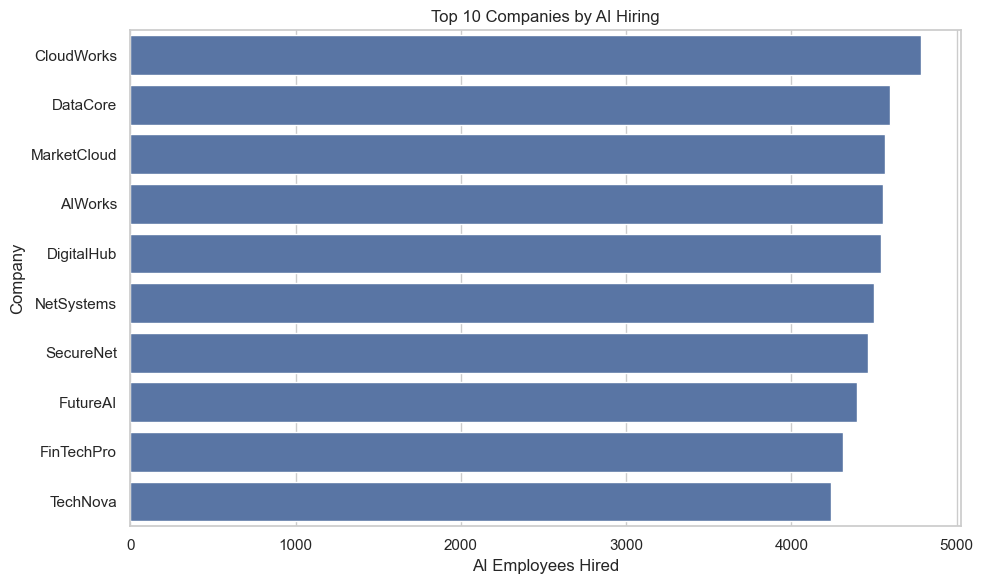

In [71]:
top_ai_hiring = company_summary.sort_values(
    "Total_AI_Hiring", ascending=False
).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_ai_hiring, x="Total_AI_Hiring", y="Company")
plt.title("Top 10 Companies by AI Hiring")
plt.xlabel("AI Employees Hired")
plt.ylabel("Company")
plt.tight_layout()
plt.show()


## 10. Year-wise Layoffs and AI Hiring Trend


,Year,Total_Layoffs,Total_AI_Hiring,Total_Tech_Hiring
0,2023,72856,12802,43176
1,2024,75487,18926,40072
2,2025,78963,23602,42905
3,2026,79583,26843,42832


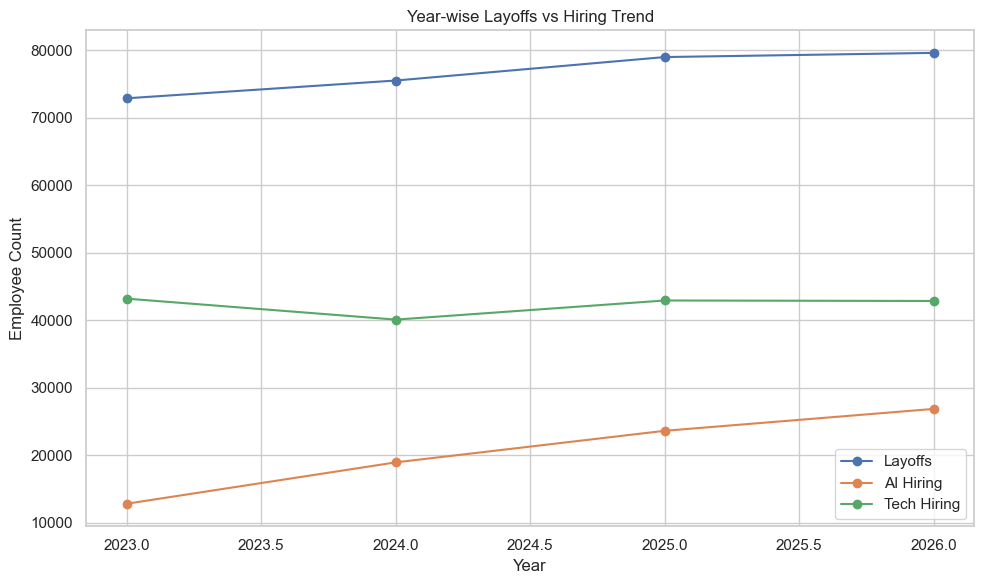

In [72]:
year_summary = df.groupby("Year", as_index=False).agg(
    Total_Layoffs=("Layoffs", "sum"),
    Total_AI_Hiring=("AI_Hiring", "sum"),
    Total_Tech_Hiring=("Tech_Hiring", "sum")
)

display(year_summary)

plt.figure(figsize=(10, 6))
plt.plot(year_summary["Year"], year_summary["Total_Layoffs"], marker="o", label="Layoffs")
plt.plot(year_summary["Year"], year_summary["Total_AI_Hiring"], marker="o", label="AI Hiring")
plt.plot(year_summary["Year"], year_summary["Total_Tech_Hiring"], marker="o", label="Tech Hiring")
plt.title("Year-wise Layoffs vs Hiring Trend")
plt.xlabel("Year")
plt.ylabel("Employee Count")
plt.legend()
plt.tight_layout()
plt.show()


## 11. Layoffs vs AI Hiring Comparison


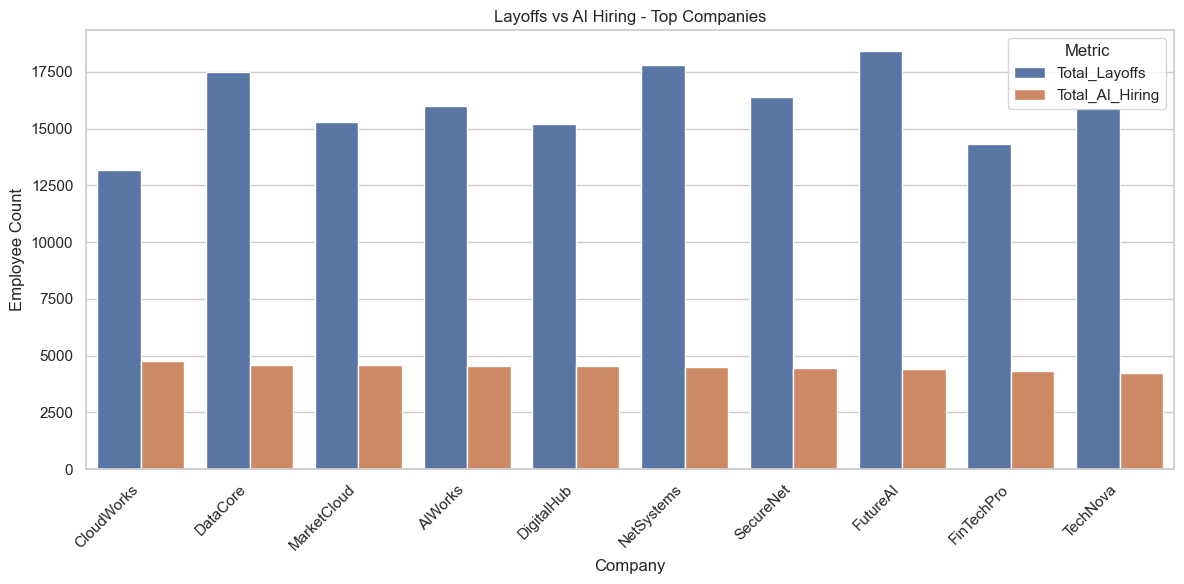

In [73]:
comparison = company_summary.head(10).melt(
    id_vars="Company",
    value_vars=["Total_Layoffs", "Total_AI_Hiring"],
    var_name="Metric",
    value_name="Employee_Count"
)

plt.figure(figsize=(12, 6))
sns.barplot(data=comparison, x="Company", y="Employee_Count", hue="Metric")
plt.title("Layoffs vs AI Hiring - Top Companies")
plt.xticks(rotation=45, ha="right")
plt.xlabel("Company")
plt.ylabel("Employee Count")
plt.tight_layout()
plt.show()


## 12. AI Job Growth by Company


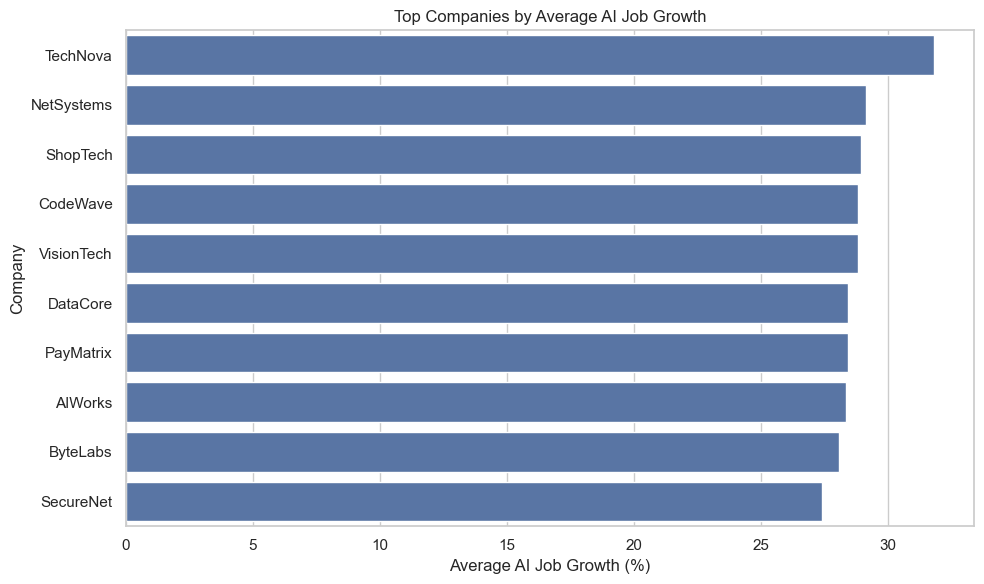

In [74]:
growth_top = company_summary.sort_values(
    "Avg_AI_Job_Growth", ascending=False
).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=growth_top, x="Avg_AI_Job_Growth", y="Company")
plt.title("Top Companies by Average AI Job Growth")
plt.xlabel("Average AI Job Growth (%)")
plt.ylabel("Company")
plt.tight_layout()
plt.show()


## 13. Layoff Rate by Company


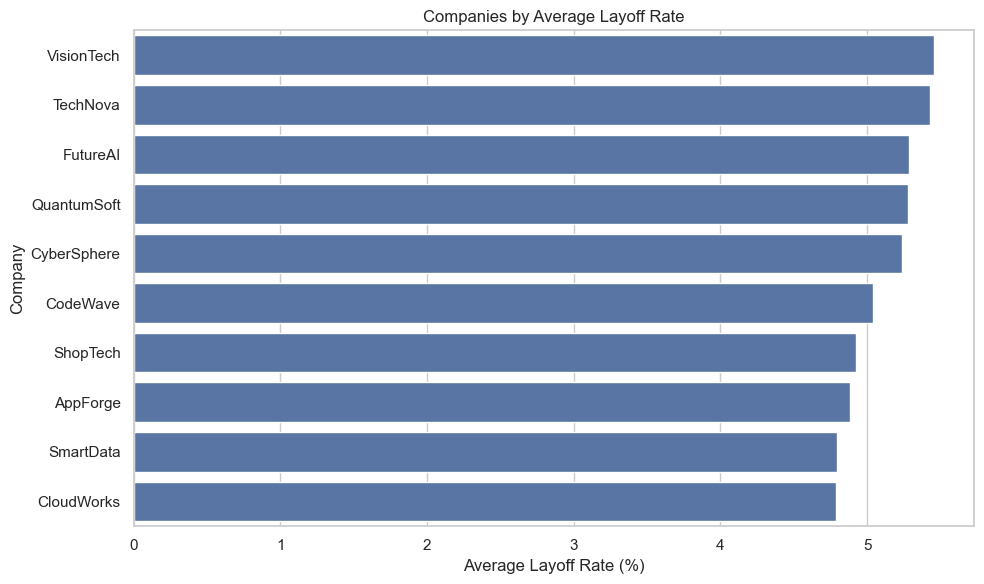

In [75]:
layoff_rate_top = company_summary.sort_values(
    "Avg_Layoff_Rate", ascending=False
).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=layoff_rate_top, x="Avg_Layoff_Rate", y="Company")
plt.title("Companies by Average Layoff Rate")
plt.xlabel("Average Layoff Rate (%)")
plt.ylabel("Company")
plt.tight_layout()
plt.show()


## 14. Industry-wise Analysis


In [76]:
industry_summary = df.groupby("Industry", as_index=False).agg(
    Total_Layoffs=("Layoffs", "sum"),
    Total_AI_Hiring=("AI_Hiring", "sum"),
    Total_Tech_Hiring=("Tech_Hiring", "sum"),
    Avg_AI_Growth=("AI_Job_Growth_Pct", "mean"),
    Avg_Layoff_Rate=("Layoff_Rate_Pct", "mean")
).sort_values("Total_AI_Hiring", ascending=False)

display(industry_summary)


,Industry,Total_Layoffs,Total_AI_Hiring,Total_Tech_Hiring,Avg_AI_Growth,Avg_Layoff_Rate
7,Software,103870,28426,59139,28.093750,4.862500
0,Artificial Intelligence,48770,12538,25527,27.156250,4.929167
2,Cloud,30963,9283,18266,26.156250,4.634375
5,E-commerce,31609,8638,17053,28.093750,4.650000
3,Cybersecurity,31389,8119,17184,26.590625,4.490625
6,FinTech,27834,7739,15762,27.059375,4.618750
1,Automation,15689,3910,9125,26.181250,4.325000
4,Data Analytics,16765,3520,6929,25.962500,4.793750


## 15. Industry-wise AI Hiring


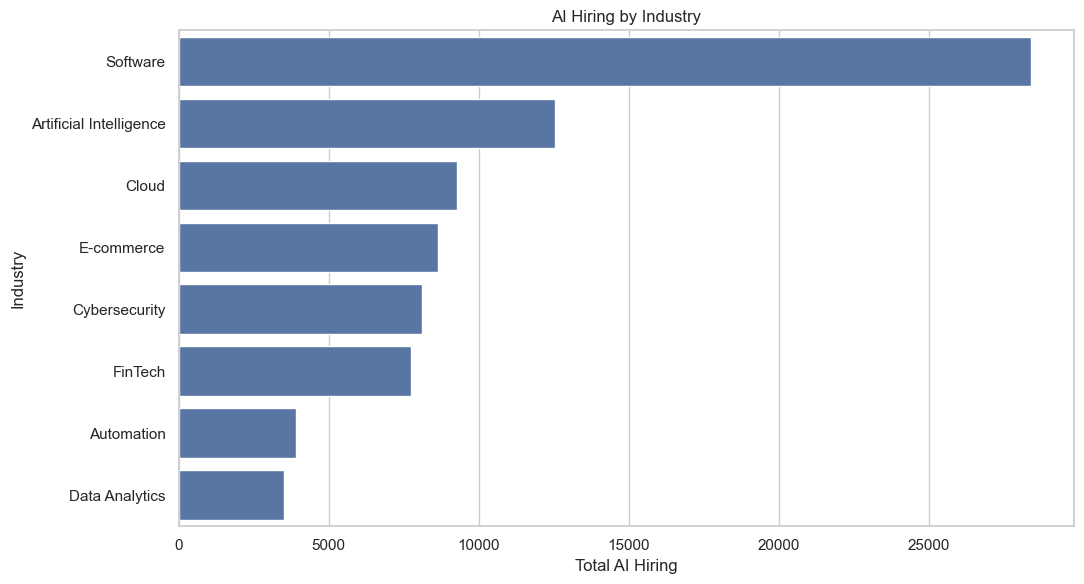

In [77]:
plt.figure(figsize=(11, 6))
sns.barplot(data=industry_summary, x="Total_AI_Hiring", y="Industry")
plt.title("AI Hiring by Industry")
plt.xlabel("Total AI Hiring")
plt.ylabel("Industry")
plt.tight_layout()
plt.show()


## 16. Location-wise Layoffs and AI Hiring


In [78]:
location_summary = df.groupby("Location", as_index=False).agg(
    Total_Layoffs=("Layoffs", "sum"),
    Total_AI_Hiring=("AI_Hiring", "sum"),
    Total_Tech_Hiring=("Tech_Hiring", "sum")
).sort_values("Total_AI_Hiring", ascending=False)

display(location_summary)


,Location,Total_Layoffs,Total_AI_Hiring,Total_Tech_Hiring
5,USA,96640,24610,53223
2,India,79712,20529,42680
4,UK,43905,12441,23468
3,Singapore,28711,8554,16690
0,Canada,28032,8146,17222
1,Germany,29889,7893,15702


## 17. Location-wise AI Hiring


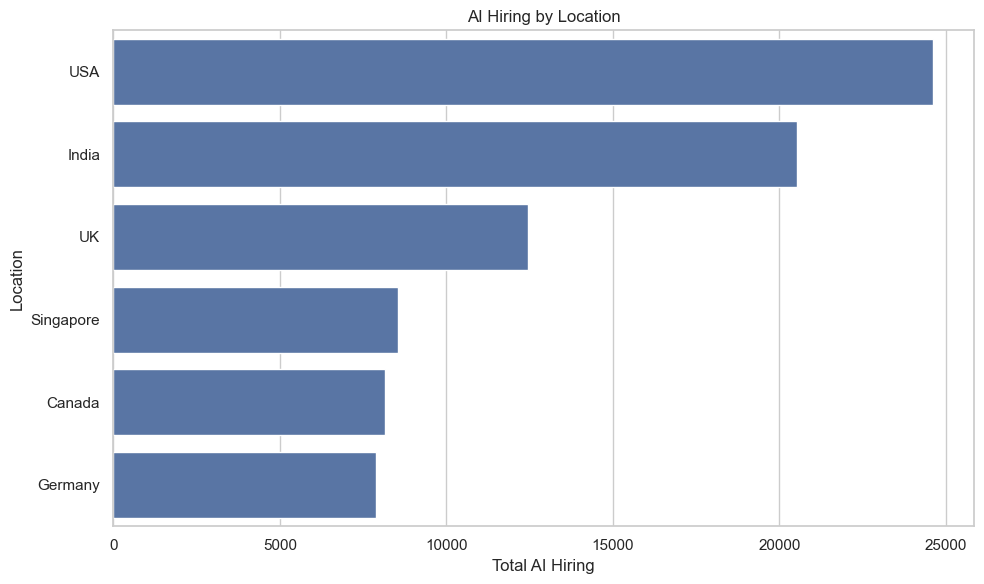

In [79]:
plt.figure(figsize=(10, 6))
sns.barplot(data=location_summary, x="Total_AI_Hiring", y="Location")
plt.title("AI Hiring by Location")
plt.xlabel("Total AI Hiring")
plt.ylabel("Location")
plt.tight_layout()
plt.show()


## 18. Quarterly Trend Analysis


In [80]:
quarter_summary = df.groupby(["Year", "Quarter"], as_index=False).agg(
    Total_Layoffs=("Layoffs", "sum"),
    Total_AI_Hiring=("AI_Hiring", "sum"),
    Total_Tech_Hiring=("Tech_Hiring", "sum")
)

quarter_summary["Period"] = (
    quarter_summary["Year"].astype(str) + "-" + quarter_summary["Quarter"]
)

display(quarter_summary.head(12))


,Year,Quarter,Total_Layoffs,Total_AI_Hiring,Total_Tech_Hiring,Period
0,2023,Q1,18297,3140,9601,2023-Q1
1,2023,Q2,19691,2653,11794,2023-Q2
2,2023,Q3,19082,3401,11295,2023-Q3
3,2023,Q4,15786,3608,10486,2023-Q4
4,2024,Q1,21398,4458,12056,2024-Q1
5,2024,Q2,17988,4683,9573,2024-Q2
6,2024,Q3,19368,4523,9866,2024-Q3
7,2024,Q4,16733,5262,8577,2024-Q4
8,2025,Q1,20852,6186,11050,2025-Q1
9,2025,Q2,20342,5727,10805,2025-Q2


## 19. Quarterly AI Hiring Trend


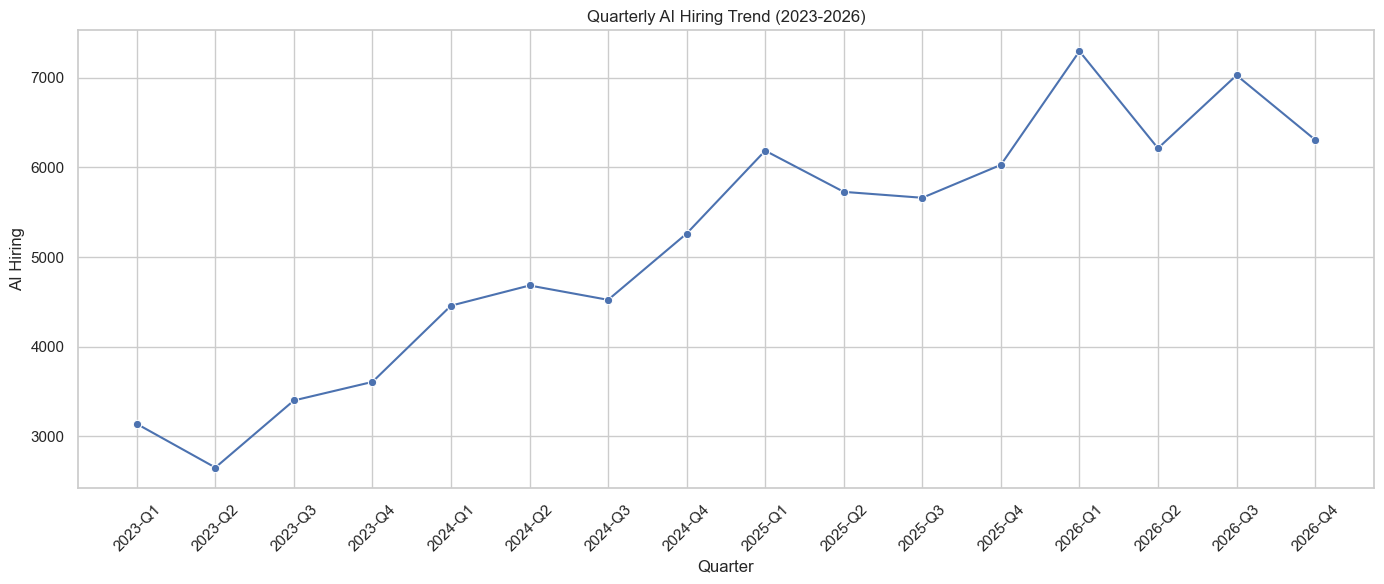

In [81]:
plt.figure(figsize=(14, 6))
sns.lineplot(
    data=quarter_summary,
    x="Period",
    y="Total_AI_Hiring",
    marker="o"
)
plt.title("Quarterly AI Hiring Trend (2023-2026)")
plt.xlabel("Quarter")
plt.ylabel("AI Hiring")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 20. AI-related Layoffs Analysis


In [82]:
ai_layoff_summary = df.groupby("AI_Related_Layoff", as_index=False).agg(
    Total_Layoffs=("Layoffs", "sum"),
    Total_AI_Hiring=("AI_Hiring", "sum"),
    Records=("ID", "count")
)

display(ai_layoff_summary)


,AI_Related_Layoff,Total_Layoffs,Total_AI_Hiring,Records
0,No,197479,53049,208
1,Yes,109410,29124,112


## 21. AI-related Layoff Distribution


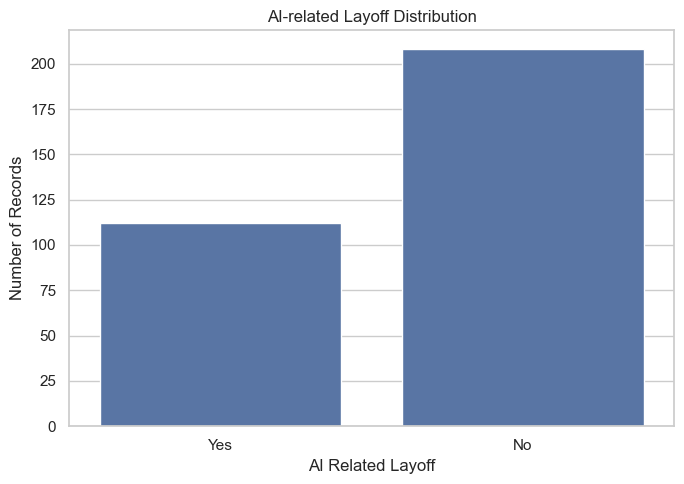

In [83]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="AI_Related_Layoff")
plt.title("AI-related Layoff Distribution")
plt.xlabel("AI Related Layoff")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()


## 22. Correlation Analysis


In [84]:
corr_cols = [
    "Layoffs",
    "AI_Hiring",
    "Tech_Hiring",
    "AI_Job_Growth_Pct",
    "Layoff_Rate_Pct",
    "AI_Hiring_Share_Pct"
]

correlation = df[corr_cols].corr()
display(correlation)


,Layoffs,AI_Hiring,Tech_Hiring,AI_Job_Growth_Pct,Layoff_Rate_Pct,AI_Hiring_Share_Pct
Layoffs,1.000000,0.093385,0.111247,0.003134,0.004623,0.001350
AI_Hiring,0.093385,1.000000,-0.006663,0.368608,-0.002372,0.707299
Tech_Hiring,0.111247,-0.006663,1.000000,-0.019681,0.015748,-0.665169
AI_Job_Growth_Pct,0.003134,0.368608,-0.019681,1.000000,0.052499,0.279723
Layoff_Rate_Pct,0.004623,-0.002372,0.015748,0.052499,1.000000,-0.031071
AI_Hiring_Share_Pct,0.001350,0.707299,-0.665169,0.279723,-0.031071,1.000000


## 23. Correlation Heatmap


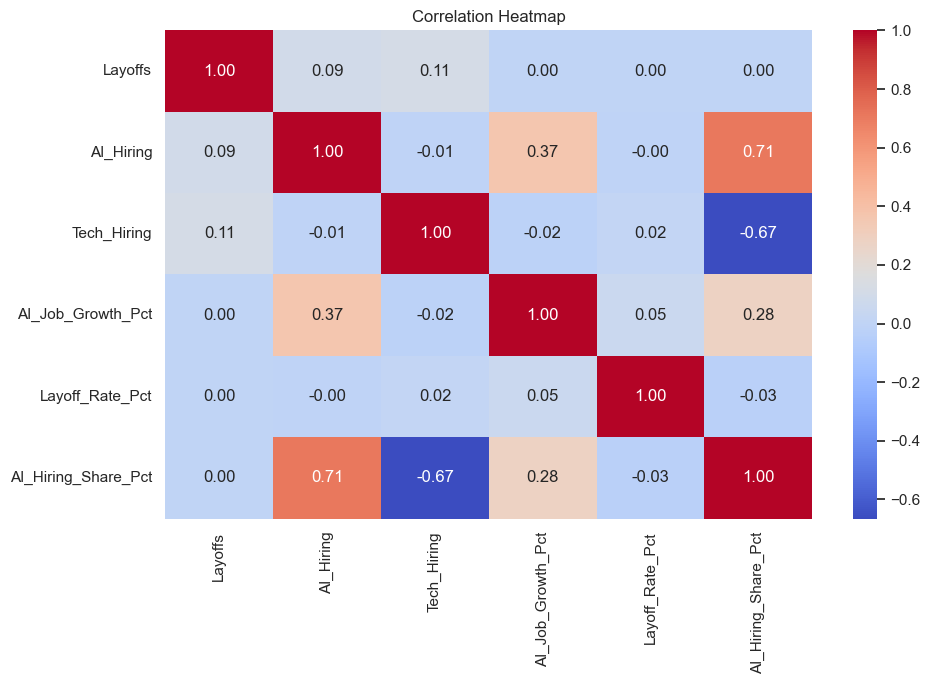

In [85]:
plt.figure(figsize=(10, 7))
sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


## 24. Layoffs vs AI Hiring


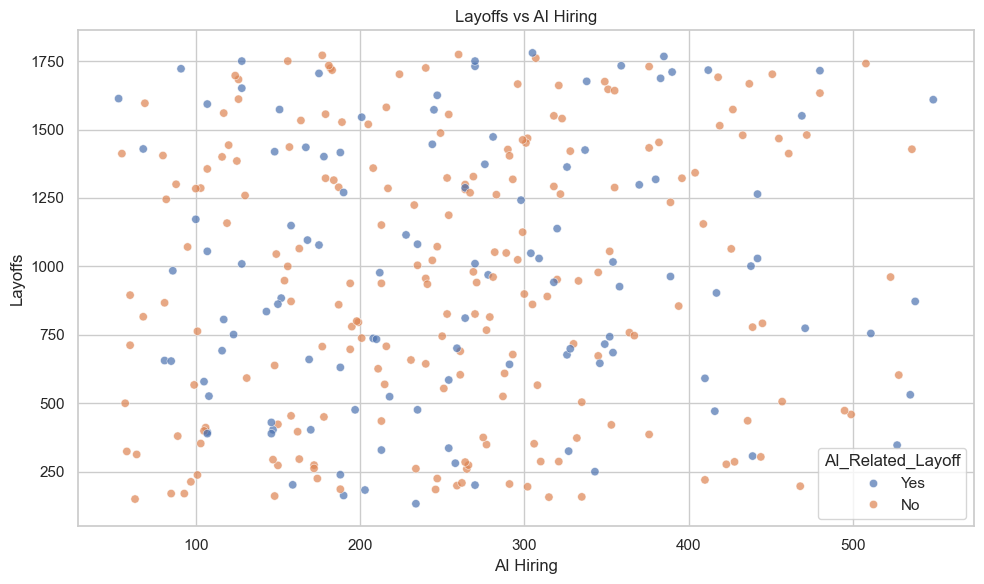

In [86]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="AI_Hiring",
    y="Layoffs",
    hue="AI_Related_Layoff",
    alpha=0.7
)
plt.title("Layoffs vs AI Hiring")
plt.xlabel("AI Hiring")
plt.ylabel("Layoffs")
plt.tight_layout()
plt.show()


## 25. AI Hiring vs AI Job Growth


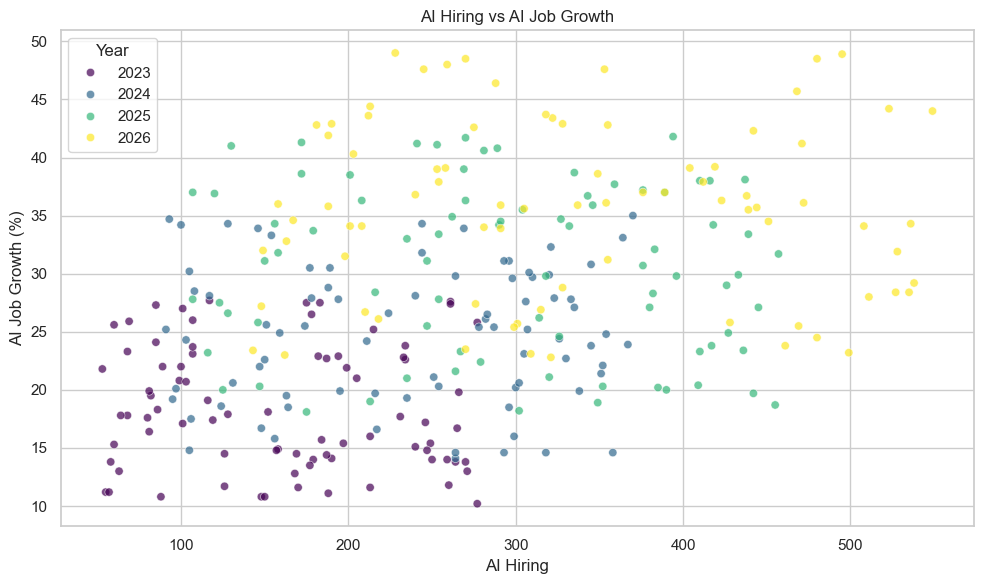

In [87]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="AI_Hiring",
    y="AI_Job_Growth_Pct",
    hue="Year",
    palette="viridis",
    alpha=0.7
)
plt.title("AI Hiring vs AI Job Growth")
plt.xlabel("AI Hiring")
plt.ylabel("AI Job Growth (%)")
plt.tight_layout()
plt.show()


## 26. AI Hiring Level Distribution


AI_Hiring_Level
High    161
Low     159
Name: count, dtype: int64

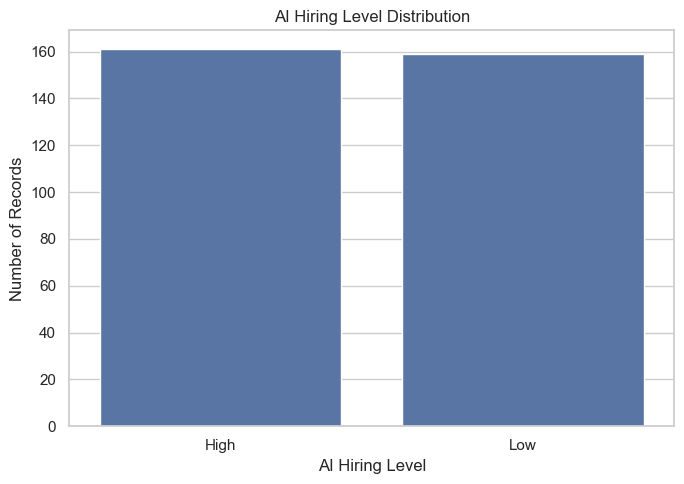

In [88]:
hiring_counts = df["AI_Hiring_Level"].value_counts()

display(hiring_counts)

plt.figure(figsize=(7, 5))
sns.barplot(x=hiring_counts.index, y=hiring_counts.values)
plt.title("AI Hiring Level Distribution")
plt.xlabel("AI Hiring Level")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()


## 27. Key Business Insights

The following outputs help identify:
- Changes in layoffs from 2023 to 2026.
- Growth in AI hiring.
- Industries with higher AI hiring.
- Locations with higher AI hiring activity.
- Companies with higher layoffs.
- Relationship between layoffs and AI hiring.
- AI-related layoff patterns.


## 28. Final Validation


In [89]:
print("Final dataset shape:", df.shape)
print("Total layoffs:", df["Layoffs"].sum())
print("Total AI hiring:", df["AI_Hiring"].sum())
print("Total tech hiring:", df["Tech_Hiring"].sum())
print("Average AI job growth:", round(df["AI_Job_Growth_Pct"].mean(), 2), "%")
print("Average layoff rate:", round(df["Layoff_Rate_Pct"].mean(), 2), "%")
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("\nNotebook analysis completed successfully.")


Final dataset shape: (320, 15)
Total layoffs: 306889
Total AI hiring: 82173
Total tech hiring: 168985
Average AI job growth: 27.3 %
Average layoff rate: 4.74 %
Missing values: 0
Duplicate rows: 0

Notebook analysis completed successfully.
